# Предсказание положения мяча на следующем кадре

Функция `match_detection` сопоставляем детекции и треки на основе предсказанных координат. Такой подход позволяет "ожидать" мяч в правильной точке. Если мяч выходит за допустимые лимиты (в match_Detection переменные `max_dist_confirmed` и `max_dist_unconfirmed`) то мы считаем, что это не тот же мяч, а новый трек. Сейчас пороги следующие:

`max_dist_confirmed = 100.0
 max_dist_unconfirmed = 30.0`

Пример работы:
Мяч движется со скоростью 6 px/кадр. Детекции пришли на кадрах 100 и 104 (разрыв 3 кадра, между ними мяч визуально пропал — фон, перекрытие).
- На кадре 100 трек получил точку (100, 200) → на кадре 101 pred = (106, 200).
- Пока идёт gap, pred больше не обновляется (`update_track` вызывается только при видимой детекции).
- На кадре 104 мяч реально в (118, 200) — улетел на 3 кадра × 6 = 18px.
- dist до pred = |118 − 106| = 12px. Это ещё проходит для confirmed (100px), но уже проваливает unconfirmed (30px) при чуть большей скорости или длиннее gap.
- Скорость 30 px/кадр и gap 3 кадра → dist = 60px → matched = {}, трек теряется.

Тоесть получается чем больше gap и быстрее мяч, тем критичнее точность pred.

Ниже представлены варианты решения этой задачи через голую линейную регрессию и через линейную регрессию, но нормализованную по `frame`

In [1]:
import numpy as np
from typing import Tuple, List, Dict
import matplotlib.pyplot as plt
from scr.MyTypes import ALLTracks, Detection

In [2]:
example_track = {
    "frame_idx": [
        3913, 3914, 3915, 3917, 3919,
        3920, 3922, 3923, 3924, 3925, 3926, 3927,
        3928, 3929, 3930, 3931, 3932, 3933, 3934, 3935, 3936,
        3942, 3943, 3944, 3945, 3946,
        3947, 3948, 3949, 3950, 3951, 3952,
        3953, 3954, 3955, 3956,
        3974, 3975, 3976, 3977,
        3980, 3981, 3982, 3983, 3984, 3985, 3986, 3988, 3989,
        3990, 3991, 3992, 3993, 3994, 3995, 3997, 3998
    ],
    "x": [
        727, 732, 735, 745, 755,
        757, 765, 767, 772, 775, 777, 777,
        780, 785, 785, 787, 792, 792, 797, 797, 802,
        837, 845, 852, 855, 865,
        870, 875, 885, 892, 895, 905,
        912, 920, 927, 930,
        567, 552, 522, 492,
        417, 405, 377, 345, 332, 302, 272, 235, 205,
        190, 167, 135, 125, 97, 72, 35, 12
    ],
    "y": [
        180, 170, 162, 140, 130,
        122, 120, 117, 115, 117, 120, 122,
        130, 135, 137, 147, 157, 162, 172, 185, 195,
        182, 172, 165, 160, 160,
        157, 155, 155, 155, 157, 160,
        165, 167, 172, 182,
        245, 230, 212, 192,
        147, 142, 130, 115, 112, 100, 90, 77, 72,
        70, 70, 65, 67, 65, 67, 70, 77
    ]
}

In [3]:
def linear_pred_calculate(x: List[int], y: List[int]) -> Tuple[int, int]:

    if x[-1] >= 0:

        x_speed = np.diff(x)[-1]
        y_speed = np.diff(y)[-1]

        pred_x = x[-1] + x_speed
        pred_y = y[-1] + y_speed

    else:

        real_values_x = [v for v in x if v >= 0]
        real_values_y = [v for v in y if v >= 0]

        if len(real_values_x) > 2:

            mean_speed_x = np.mean(np.diff(real_values_x)[-10:])
            mean_speed_y = np.mean(np.diff(real_values_y)[-10:])

            pred_x = x[-2] + mean_speed_x
            pred_y = y[-2] + mean_speed_y

        else:
            return real_values_x[-1], real_values_y[-1]

    return int(pred_x), int(pred_y)

In [4]:
def linear_pred_norm_frame(x: List[int], y: List[int], frames: List[int]) -> Tuple[int, int]:

    if x[-1] >= 0:

        x_speed = np.diff(x)[-1] / (np.diff(frames)[-1] + 1e-6)
        y_speed = np.diff(y)[-1] / (np.diff(frames)[-1] + 1e-6)

        pred_x = x[-1] + x_speed
        pred_y = y[-1] + y_speed

    else:

        real_values_x = [v for v in x if v >= 0]
        real_values_y = [v for v in y if v >= 0]

        if len(real_values_x) > 2:

            mean_speed_x = np.mean(np.diff(real_values_x)[-10:])
            mean_speed_y = np.mean(np.diff(real_values_y)[-10:])

            pred_x = x[-2] + mean_speed_x
            pred_y = y[-2] + mean_speed_y

        else:
            return real_values_x[-1], real_values_y[-1]

    return int(pred_x), int(pred_y)

In [5]:
pred_lin = []
pred_norm = []

for i in range(1, len(example_track["x"])):
    x_pref = example_track["x"][:i+1]
    y_pref = example_track["y"][:i+1]
    f_pref = example_track["frame_idx"][:i+1]

    pred_x_lin, pred_y_lin = linear_pred_calculate(x_pref, y_pref)
    pred_x_norm, pred_y_norm = linear_pred_norm_frame(x_pref, y_pref, f_pref)

    pred_lin.append((pred_x_lin, pred_y_lin))
    pred_norm.append((pred_x_norm, pred_y_norm))

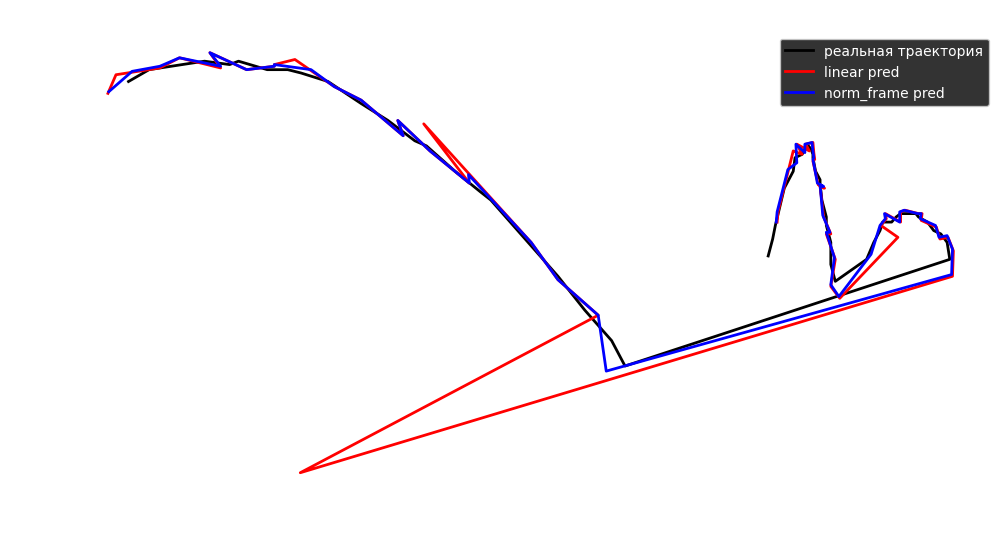

In [6]:
def plot_tracks(x, y, pred_lin, pred_norm):

    """
    Функция отрисовки на белом листе трёх траекторий линиями:
    реальной детекции и двух вариантов предсказания.

    :param x: List[int] – реальные x-координаты трека
           y: List[int] – реальные y-координаты трека
           pred_lin: List[Tuple[int, int]] – предсказанные точки линейным pred
           pred_norm: List[Tuple[int, int]] – предсказанные точки нормированным pred
    """

    plt.figure(figsize=(12, 6), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    ax.plot(x, y, label="реальная траектория", color="black", linewidth=2)
    ax.plot([p[0] for p in pred_lin], [p[1] for p in pred_lin],
            label="linear pred", color="red", linewidth=2)
    ax.plot([p[0] for p in pred_norm], [p[1] for p in pred_norm],
            label="norm_frame pred", color="blue", linewidth=2)
    ax.invert_yaxis()

    ax.legend()
    ax.set_title("Траектория мяча: реальная vs предсказанные")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid()

    plt.show()


plot_tracks(example_track["x"], example_track["y"], pred_lin, pred_norm)

Часть видео с example_track. В самом видео этот трек это несколько треков, для удобства демонстрации объеденил их в 1

<img src="pred_demonstration.gif" width="700">

На треке `example_track` сравнили два способа предсказания позиции на следующий кадр:
без нормализации (линейный pred) и с нормализацией по номеру кадра.

Главное расхождение сосредоточено на участках с разрывом детекций (gap), где
`frame[i+1] - frame[i] > 1`:

- линейный pred считает скорость как `x[i] - x[i-1]` — то есть принимает всё
  перемещение за один шаг, завышая скорость в N раз (где N — число пропущенных кадров);
- в нормализованном pred скорость делится на реальную разницу кадров
  `(x[i] - x[i-1]) / (frame[i] - frame[i-1])`, поэтому скорость — честные px/кадр.

На сплошных участках (без разрывов) формулы дают одинаковый результат, поэтому на
графике pred-линии почти совпадают, а всплески расхождения видны ровно на gap-переходах.

Вывод: нормализация по кадрам нужна для устойчивости предсказания (и, как следствие,
матчинга) при пропуске кадрах детекции — именно она используется в пайплайне в
`pred_calculate` (`scr/tracker.py`).
Есть пара опечаток в черновике («следующийку», «пропуске», «матчинга») — при вставке выправь. Хочешь, чтобы я переписал почище (без опечаток) или оставляешь, чтобы ты сам привёл к своему стилю?

# Матчинг

Задача матчинга — сопоставлять новые детекции с существующими треками.

В ходе тестирования были обнаружены следующие проблемы:

- При наличии хотя бы одного confirmed-трека поиск среди unconfirmed не выполнялся, даже если confirmed-трек находился значительно дальше новой детекции. В результате реальные объекты не сопоставлялись с существующими треками.
- Для confirmed и unconfirmed треков использовался одинаковый порог сопоставления (100 px), из-за чего новые шумовые треки могли ошибочно объединяться с детекциями.

В ходе экспериментов были реализованы следующие изменения:

1. Исправлена логика поиска соответствия: если ни один confirmed-трек не удовлетворяет условию сопоставления, выполняется поиск среди unconfirmed-треков.
2. Введены раздельные пороги сопоставления:
   - confirmed — 100 px;
   - unconfirmed — 30 px.
3. Для unconfirmed-треков уменьшен допустимый радиус сопоставления, что позволило существенно снизить количество ложных объединений шумовых треков с реальными детекциями без ухудшения качества восстановления настоящих треков.

Ниже представлены версии матчинга и его отработка на различных сценариях

In [7]:
def v1_match_detection(all_track, detections):

    max_dist = 100.0
    matched = {}

    if detections["visible"] == 0:
        return matched

    confirmed_tracks = {k: v for k, v in all_track.items() if v["confirmed"] is True}
    unconfirmed_tracks = {k: v for k, v in all_track.items() if v["confirmed"] is False}

    best_track_id = None
    best_dist = float('inf')

    for track_id, track in confirmed_tracks.items():
        dx = track["pred_x"][-1] - detections["x"]
        dy = track["pred_y"][-1] - detections["y"]
        dist = (dx * dx + dy * dy) ** 0.5
        if dist < best_dist:
            best_dist = dist
            best_track_id = track_id

    if best_track_id is not None:
        if best_dist < max_dist:
            matched[best_track_id] = detections
    else:
        for track_id, track in unconfirmed_tracks.items():
            dx = track["pred_x"][-1] - detections["x"]
            dy = track["pred_y"][-1] - detections["y"]
            dist = (dx * dx + dy * dy) ** 0.5
            if dist < best_dist:
                best_dist = dist
                best_track_id = track_id
        if best_track_id is not None and best_dist < max_dist:
            matched[best_track_id] = detections

    return matched

In [8]:
def v2_match_detection(all_track, detections):

    max_dist = 100.0
    matched = {}

    if detections["visible"] == 0:
        return matched

    confirmed_tracks = {k: v for k, v in all_track.items() if v["confirmed"] is True}
    unconfirmed_tracks = {k: v for k, v in all_track.items() if v["confirmed"] is False}

    best_track_id = None
    best_dist = float('inf')

    for track_id, track in confirmed_tracks.items():
        dx = track["pred_x"][-1] - detections["x"]
        dy = track["pred_y"][-1] - detections["y"]
        dist = (dx * dx + dy * dy) ** 0.5
        if dist < best_dist:
            best_dist = dist
            best_track_id = track_id

    if best_track_id is not None and best_dist < max_dist:
        matched[best_track_id] = detections
    else:
        best_track_id = None
        best_dist = float('inf')

        for track_id, track in unconfirmed_tracks.items():
            dx = track["pred_x"][-1] - detections["x"]
            dy = track["pred_y"][-1] - detections["y"]
            dist = (dx * dx + dy * dy) ** 0.5
            if dist < best_dist:
                best_dist = dist
                best_track_id = track_id
        if best_track_id is not None and best_dist < max_dist:
            matched[best_track_id] = detections

    return matched

In [9]:
def v3_match_detection(all_track: ALLTracks, detections: Detection) -> Dict[int, Detection]:

    max_dist_confirmed = 100.0
    max_dist_unconfirmed = 30.0

    matched = {}

    best_track_id = None
    best_dist = float('inf')

    if detections["visible"] == 0:
        return matched

    confirmed_tracks = {key: value for key, value in all_track.items() if value["confirmed"] is True}
    unconfirmed_tracks = {key: value for key, value in all_track.items() if value["confirmed"] is False}

    for track_id, track in confirmed_tracks.items():

        dx = track["pred_x"][-1] - detections["x"]
        dy = track["pred_y"][-1] - detections["y"]
        dist = (dx * dx + dy * dy) ** 0.5

        if dist < best_dist:
            best_dist = dist
            best_track_id = track_id

    if best_track_id is not None and best_dist < max_dist_confirmed:
        matched[best_track_id] = detections

    else:
        best_track_id = None
        best_dist = float('inf')

        for track_id, track in unconfirmed_tracks.items():

            dx = track["pred_x"][-1] - detections["x"]
            dy = track["pred_y"][-1] - detections["y"]
            dist = (dx * dx + dy * dy) ** 0.5

            if dist < best_dist:
                best_dist = dist
                best_track_id = track_id

        if best_track_id is not None and best_dist < max_dist_unconfirmed:
            matched[best_track_id] = detections

    return matched

In [10]:
scenario_1_tracks = {
    1: {"confirmed": True, #реальный мяч, но находится далеко от объекта
        "pred_x": [500],
        "pred_y": [500],},
    2: {"confirmed": False, #новый трек, не подтвержден, возможно шум
        "pred_x": [105],
        "pred_y": [100],}}

scenario_1_detection = {"visible": 1, #детекция реального мяча
                        "x": 100,
                        "y": 100}

scenario_2_tracks = {
    1: {"confirmed": True, #реальный мяч, но находится далеко от объекта
        "pred_x": [500],
        "pred_y": [500]},
    2: {"confirmed": False, #шумовой неподтвержденый трек, находится далеко от текущей детекции (70px)
        "pred_x": [170],
        "pred_y": [100],}}

scenario_2_detection = {"visible": 1, #детекция реального мяча
                        "x": 100,
                        "y": 100}


scenario_3_tracks = {
    1: {"confirmed": True, #реальный мяч, но находится далеко от объекта
        "pred_x": [500],
        "pred_y": [500]},
    2: {"confirmed": False, #новый неподтвержденный трек, но находится в области матчинга (5px) от детекции
        "pred_x": [105],
        "pred_y": [100]},
    3: {"confirmed": False, #шумовой неподтвержденый трек
        "pred_x": [160],
        "pred_y": [100]}}

scenario_3_detection = {"visible": 1, #детекция реального мяча
                       "x": 100,
                       "y": 100}

In [11]:
tests = [("Scenario 1", scenario_1_tracks, scenario_1_detection),
         ("Scenario 2", scenario_2_tracks, scenario_2_detection),
         ("Scenario 3", scenario_3_tracks, scenario_3_detection)]

funcs = [
    ("v1", v1_match_detection),
    ("v2", v2_match_detection),
    ("v3", v3_match_detection)]

for name, tracks, det in tests:
    print(f"\n{name}")
    for func_name, func in funcs:
        print(f"{func_name}: {func(tracks, det)}")


Scenario 1
v1: {}
v2: {2: {'visible': 1, 'x': 100, 'y': 100}}
v3: {2: {'visible': 1, 'x': 100, 'y': 100}}

Scenario 2
v1: {}
v2: {2: {'visible': 1, 'x': 100, 'y': 100}}
v3: {}

Scenario 3
v1: {}
v2: {2: {'visible': 1, 'x': 100, 'y': 100}}
v3: {2: {'visible': 1, 'x': 100, 'y': 100}}


v1 — наличие любого confirmed-трека блокирует поиск по unconfirmed, даже если confirmed очень далеко.

v2 — поиск по unconfirmed уже работает, но из-за порога 100 px к существующему треку может приклеиться шумовая детекция.

v3 — использует раздельные пороги (100 px для confirmed и 30 px для unconfirmed), поэтому корректно восстанавливает настоящий трек и не объединяет шумовые. Это очень наглядно и хорошо ложится в раздел диплома с обоснованием изменений алгоритма.